<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 144.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 184.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [10]:
# Cheking dataset summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [17]:
# Remove duplicates by default keep the first occurrence and removes subsequent identical rows
df_clean = df.drop_duplicates()

# Identifying missing values for all columns
missing_values = df_clean.isnull().sum()

# Calculating the percentage of missing values
missing_summary = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": df_clean.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary.head(10)

,Missing Values,Missing Percentage
AINextMuch less integrated,64289,98.245641
AINextLess integrated,63082,96.401119
AINextNo change,52939,80.900714
AINextMuch more integrated,51999,79.464217
EmbeddedAdmired,48704,74.428840
EmbeddedWantToWorkWith,47837,73.103901
EmbeddedHaveWorkedWith,43223,66.052845
ConvertedCompYearly,42002,64.186928
AIToolNot interested in Using,41023,62.690832
AINextMore integrated,41009,62.669438


In [19]:
# Missing values percentage
missing_percentage = df.isnull().mean() * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

missing_percentage.head(10)

AINextMuch less integrated       98.245909
AINextLess integrated            96.401669
AINextNo change                  80.900576
AINextMuch more integrated       79.465827
EmbeddedAdmired                  74.428163
EmbeddedWantToWorkWith           73.103427
EmbeddedHaveWorkedWith           66.051920
ConvertedCompYearly              64.192400
AIToolNot interested in Using    62.695005
AINextMore integrated            62.673614
dtype: float64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



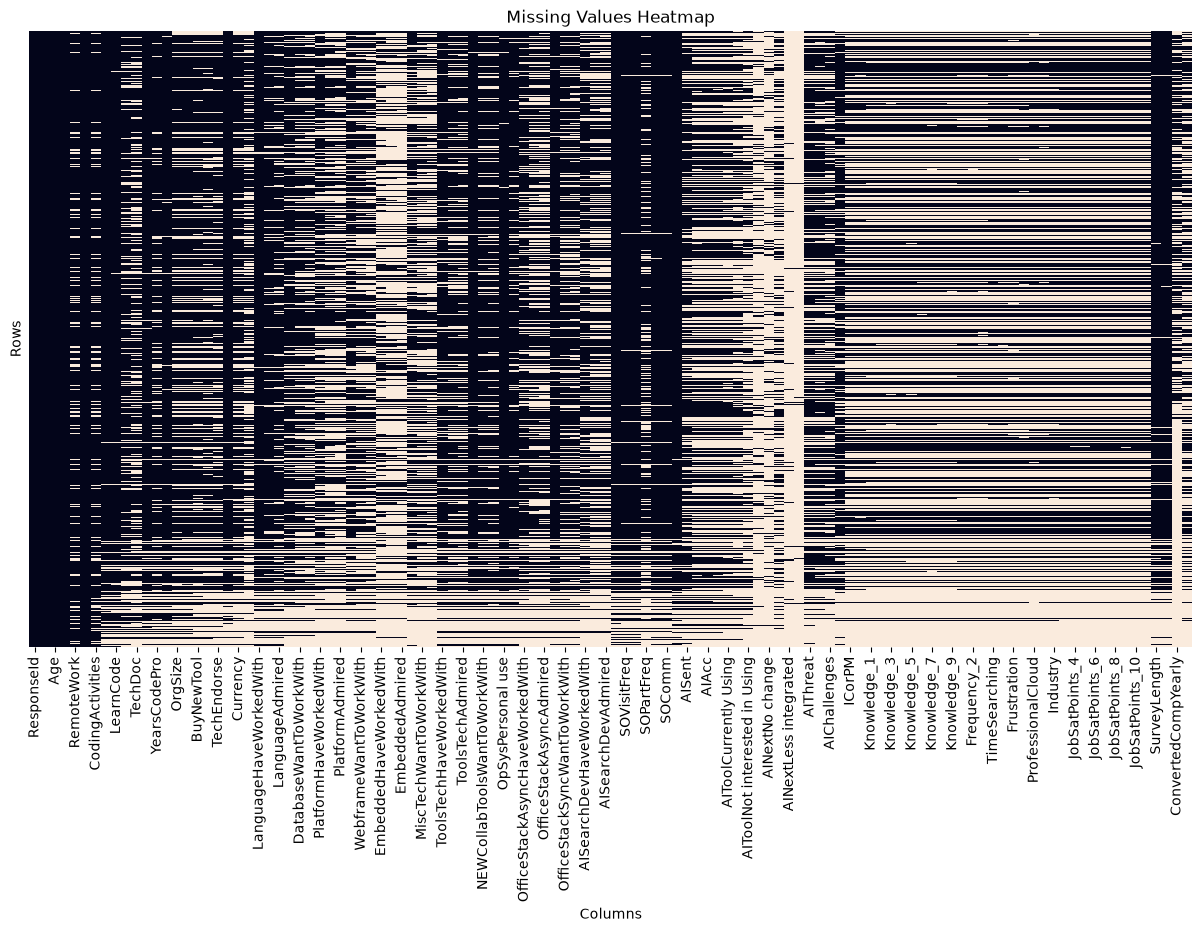

In [24]:
# Creating a missing-value heatmap
plt.figure(figsize=(15,8))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [28]:
# Missing rows for column RemoteWork
missing_remotework = df_clean["RemoteWork"].isnull().sum()
print(f"Missing values in RemoteWork: {missing_remotework}")

Missing values in RemoteWork: 10631

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [31]:
# Identifying the majority for RemoteWork
majority_value = df_clean["RemoteWork"].mode()[0]
print(f"Most frequent RemoteWork value: {majority_value}")

# Other way to identify the majority using count_values()
remote_work_counts = df["RemoteWork"].value_counts()
print(remote_work_counts)

majority_value2 = remote_work_counts.idxmax()
print(f"Most frequent RemoteWork value: {majority_value2}")

Most frequent RemoteWork value: Hybrid (some remote, some in-person)
RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20836
In-person                               10961
Name: count, dtype: int64
Most frequent RemoteWork value: Hybrid (some remote, some in-person)

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [38]:
# Imputing missing values at RemoteWork column with the most frequent value
df_clean["RemoteWork"] = df_clean["RemoteWork"].fillna(majority_value)

# Verifying missing values after inputing
remotework_missing_values_after = df_clean["RemoteWork"].isnull().sum()
print(f"Number of missing values in RemoteWork after imputation: {remotework_missing_values_after}")

Number of missing values in RemoteWork after imputation: 0

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


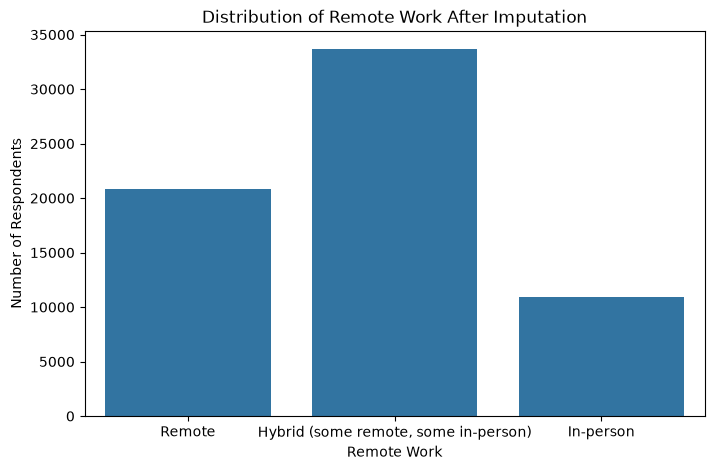

In [40]:
# Visulizing the distribution of RemoteWork after imputation
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="RemoteWork")

plt.title("Distribution of Remote Work After Imputation")
plt.xlabel("Remote Work")
plt.ylabel("Number of Respondents")

plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
